In [5]:
# Use California Housing Dataset (built-in)
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['price'] = housing.target

X = df.drop('price', axis=1)
y = df['price']

print(df.head())
print(df.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
(20640, 9)


In [7]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load built-in dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['price'] = housing.target

# Define X and y
X = df.drop('price', axis=1)
y = df['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

✅ Dataset loaded successfully!
Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [8]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
import numpy as np

# KFold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = Ridge()
scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')

rmse_scores = np.sqrt(-scores)
print("RMSE per fold:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

RMSE per fold: [0.74552228 0.72640228 0.71365563 0.71054941 0.74509773]
Mean RMSE: 0.7282454657127894
Std RMSE: 0.014912397347095476


In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso

# Ridge Tuning
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)
print("Best Ridge Alpha:", ridge_grid.best_params_)

# Lasso Tuning
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(), lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train, y_train)
print("Best Lasso Alpha:", lasso_grid.best_params_)

Best Ridge Alpha: {'alpha': 0.1}
Best Lasso Alpha: {'alpha': 0.001}


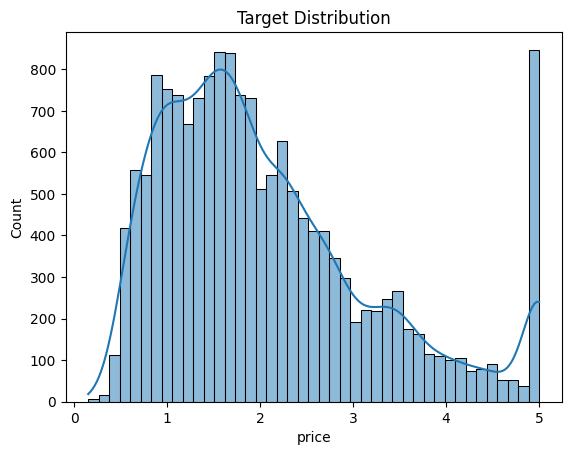

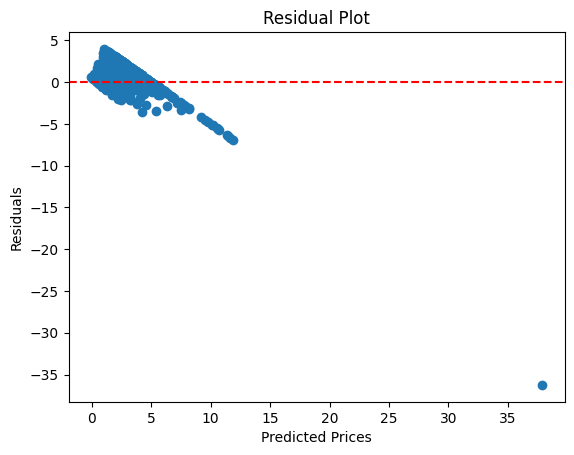

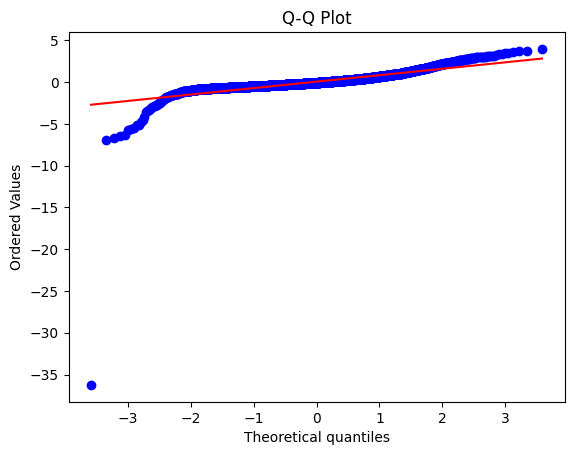

In [10]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Check if target is skewed
import seaborn as sns
sns.histplot(y_train, kde=True)
plt.title("Target Distribution")
plt.show()

# Apply Log Transform if skewed
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Train model on log target
model = Ridge(alpha=ridge_grid.best_params_['alpha'])
model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)

# Convert back to original scale
y_pred = np.expm1(y_pred_log)

# Residual Plot
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [11]:
from sklearn.metrics import mean_squared_error

# Baseline: always predict mean
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

# Your model
model_pred = model.predict(X_test)
model_rmse = np.sqrt(mean_squared_error(y_test, np.expm1(model_pred)))

print(f"Baseline RMSE : {baseline_rmse:.2f}")
print(f"Model RMSE    : {model_rmse:.2f}")
print(f"Improvement   : {baseline_rmse - model_rmse:.2f}")

Baseline RMSE : 1.14
Model RMSE    : 0.98
Improvement   : 0.16


Top 10 Worst Predictions:
        Actual  Predicted      Error
1979   1.62500  37.866321  36.241321
15693  5.00001  11.902454   6.902444
9811   5.00001  11.651794   6.651784
17110  5.00001  11.490530   6.490520
17108  5.00001  11.367810   6.367800
4605   5.00001  10.675355   5.675345
4678   5.00001  10.639134   5.639124
8852   5.00001  10.509067   5.509057
6590   5.00001  10.161988   5.161978
5304   5.00001  10.078669   5.078659


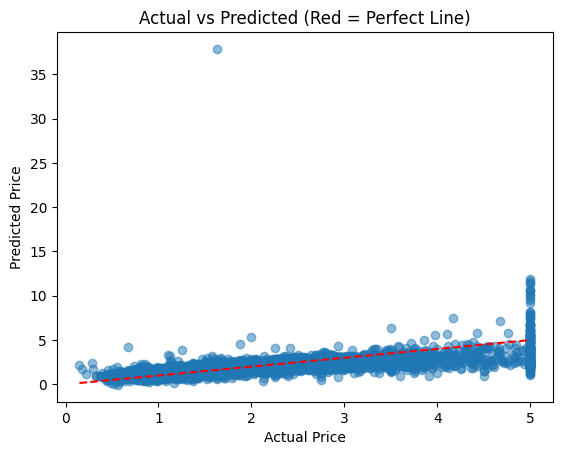

In [12]:
import pandas as pd

# Find worst predictions
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': np.expm1(y_pred_log),
    'Error': np.abs(y_test - np.expm1(y_pred_log))
})

# Sort by highest error
worst_cases = results.sort_values('Error', ascending=False).head(10)
print("Top 10 Worst Predictions:")
print(worst_cases)

# Visualize
plt.scatter(results['Actual'], results['Predicted'], alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Red = Perfect Line)")
plt.show()

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Pipeline: Polynomial + Ridge
poly_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=10))
])

poly_ridge.fit(X_train, y_train_log)
poly_pred = np.expm1(poly_ridge.predict(X_test))

poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))
print(f"Polynomial + Ridge RMSE: {poly_rmse:.2f}")

Polynomial + Ridge RMSE: 0.66


In [15]:

from sklearn.metrics import mean_squared_error

# 1. Baseline RMSE
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

# 2. Ridge RMSE
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

# 3. Lasso RMSE
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

# 4. Polynomial + Ridge RMSE
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=10))
])
poly_ridge.fit(X_train, y_train)
poly_pred = poly_ridge.predict(X_test)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))

print("✅ All RMSE values calculated!")
print(f"Baseline RMSE : {baseline_rmse:.2f}")
print(f"Ridge RMSE    : {ridge_rmse:.2f}")
print(f"Lasso RMSE    : {lasso_rmse:.2f}")
print(f"Poly+Ridge RMSE: {poly_rmse:.2f}")

✅ All RMSE values calculated!
Baseline RMSE : 1.14
Ridge RMSE    : 0.75
Lasso RMSE    : 0.74
Poly+Ridge RMSE: 0.67


In [16]:
results_summary = pd.DataFrame({
    'Model': ['Baseline', 'Ridge', 'Lasso', 'Poly + Ridge'],
    'RMSE': [baseline_rmse, ridge_rmse, lasso_rmse, poly_rmse]
})

print(results_summary.sort_values('RMSE'))

          Model      RMSE
3  Poly + Ridge  0.671548
2         Lasso  0.740442
1         Ridge  0.745342
0      Baseline  1.144856
